# SAM — Otomatik Segmentasyon

Bu notebook, Meta'nın **Segment Anything Model (SAM)** kullanarak bir görüntüdeki tüm nesneleri
otomatik olarak segmentler.

## 1 — Kütüphanelerin Kurulması


| Kütüphane | Görev |
|---|---|
| `segment-anything` | SAM'in model kodu (Meta) |
| `supervision` | Maske görselleştirme (Roboflow) |
| `pycocotools` | COCO formatı desteği |
| `opencv-python-headless` | Görüntü okuma/yazma (Colab'de `headless` tercih edilir) |


In [1]:
# ── Kurulum ──────────────────────────────────────────────────────────────────
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'
!pip install -q supervision pycocotools opencv-python-headless


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.5 MB/s eta 0:00:00


## 2 — İmportlar ve Konfigürasyon



Yapay zeka modelleri, eğitildikten sonra öğrendikleri bilgileri devasa birer sayısal dosya (ağırlık dosyası) olarak saklarlar. SAM'in üç farklı boyutu vardır (Base, Large, Huge). Biz en güçlüsü olan ViT-H (Huge) modelini kullanacağız.

In [2]:
# ── Standart kütüphaneler ─────────────────────────────────────────────────────
import os
import sys

# ── Üçüncü taraf kütüphaneler ────────────────────────────────────────────────
import cv2
import torch
import matplotlib.pyplot as plt
import supervision as sv
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

%matplotlib inline

# ── Kullanıcı ayarları (buradan değiştir) ────────────────────────────────────
IMAGE_NAME  = "deneme.jpeg"   # Colab'e yüklediğin dosyanın adı
MODEL_TYPE  = "vit_h"         # "vit_b" (hızlı) | "vit_l" | "vit_h" (en iyi)
RESULT_NAME = "segmentasyon_sonucu.png"

# ── Ağırlık dosyası URL'leri ─────────────────────────────────────────────────
CHECKPOINT_URLS = {
    "vit_b": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
    "vit_l": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth",
    "vit_h": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth",
}

# ── Yollar ───────────────────────────────────────────────────────────────────
HOME            = os.getcwd()
WEIGHTS_DIR     = os.path.join(HOME, "weights")
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, os.path.basename(CHECKPOINT_URLS[MODEL_TYPE]))
IMAGE_PATH      = os.path.join(HOME, IMAGE_NAME)
RESULT_PATH     = os.path.join(HOME, RESULT_NAME)

os.makedirs(WEIGHTS_DIR, exist_ok=True)   # exist_ok=True → if/else'e gerek yok

print(f"Çalışma dizini : {HOME}")
print(f"Model tipi     : {MODEL_TYPE}")
print(f"Ağırlık dosyası: {CHECKPOINT_PATH}")
print(f"Giriş resmi    : {IMAGE_PATH}")
print(f"Çıktı resmi    : {RESULT_PATH}")


Çalışma dizini : /content
Model tipi     : vit_h
Ağırlık dosyası: /content/weights/sam_vit_h_4b8939.pth
Giriş resmi    : /content/deneme.jpeg
Çıktı resmi    : /content/segmentasyon_sonucu.png


## 3 — Model Ağırlıklarını İndirme

`-c` (continue) bayrağı sayesinde indirme yarıda kesilse bile kaldığı yerden devam eder.
Dosya zaten tam indirildiyse wget hiçbir şey yapmaz.


In [3]:
# ── Model ağırlıklarını indir ─────────────────────────────────────────────────
# -c  : yarım indirmeye devam et
# -nv : gereksiz çıktıyı kapat
!wget -c -nv "{CHECKPOINT_URLS[MODEL_TYPE]}" -P "{WEIGHTS_DIR}"

# Dosyanın varlığını doğrula; yoksa scripti durdur
if not os.path.isfile(CHECKPOINT_PATH):
    sys.exit(f"HATA: Ağırlık dosyası bulunamadı → {CHECKPOINT_PATH}")

print(f"Ağırlık dosyası hazır: {CHECKPOINT_PATH}")
print(f"Dosya boyutu: {os.path.getsize(CHECKPOINT_PATH) / 1e9:.2f} GB")


2026-05-15 14:48:46 URL:https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth [2564550879/2564550879] -> "/content/weights/sam_vit_h_4b8939.pth" [1]
Ağırlık dosyası hazır: /content/weights/sam_vit_h_4b8939.pth
Dosya boyutu: 2.56 GB


## 4 — Modeli Yükleme ve GPU Kontrolü
Ağırlıkları indirdik, şimdi bu ağırlıkları SAM'in kod yapısına (mimarisine) yükleyip ekran kartına (GPU) göndereceğiz. Yapay zeka işlemleri binlerce matematiksel çarpma işlemi gerektirdiği için bunu işlemcide (CPU) değil, ekran kartında (GPU) yapmak hızımızı 10-20 kat artırır.



Colab'da **Çalışma Zamanı → Çalışma zamanı türünü değiştir → T4 GPU** seçin.


In [4]:
# ── Cihaz seç ────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {DEVICE}")
if DEVICE.type == "cpu":
    print("⚠️  GPU bulunamadı. İşlem yavaş olacak. Colab'da GPU'yu etkinleştirin.")

# ── Modeli yükle ──────────────────────────────────────────────────────────────
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE)
sam.eval()          # Dropout/BN katmanlarını inference moduna al

print("Model başarıyla yüklendi!")


Cihaz: cuda:0
Model başarıyla yüklendi!


## 5 — Görüntü Yükleme

Bir yapay zeka modeli görüntüyü doğrudan "görmez"; görüntüyü sayılardan oluşan bir matris (array) olarak okur. Bu adımda kendi resmimizi Colab'e yükleyeceğiz ve modelin anlayacağı formata getireceğiz.


Bilgisayarından bir resim seç (ismini deneme.jpeg yaparsan kodla uyumlu olur) ve Colab'in sol panelindeki "Files" (Dosyalar) kısmına sürükle **veya** aşağıdaki kodu kod hücresine yapıştırın:
```python
# Google Drive'dan yüklemek için:
from google.colab import drive
drive.mount('/content/drive')
IMAGE_PATH = "/content/drive/MyDrive/resim.jpg"
```

**Önemli:** `cv2.imread` hata fırlatmaz; dosya bulunamazsa `None` döner.
Bu yüzden açık kontrol yapıyoruz.


Görüntü boyutu: 736x981 px, 3 kanal


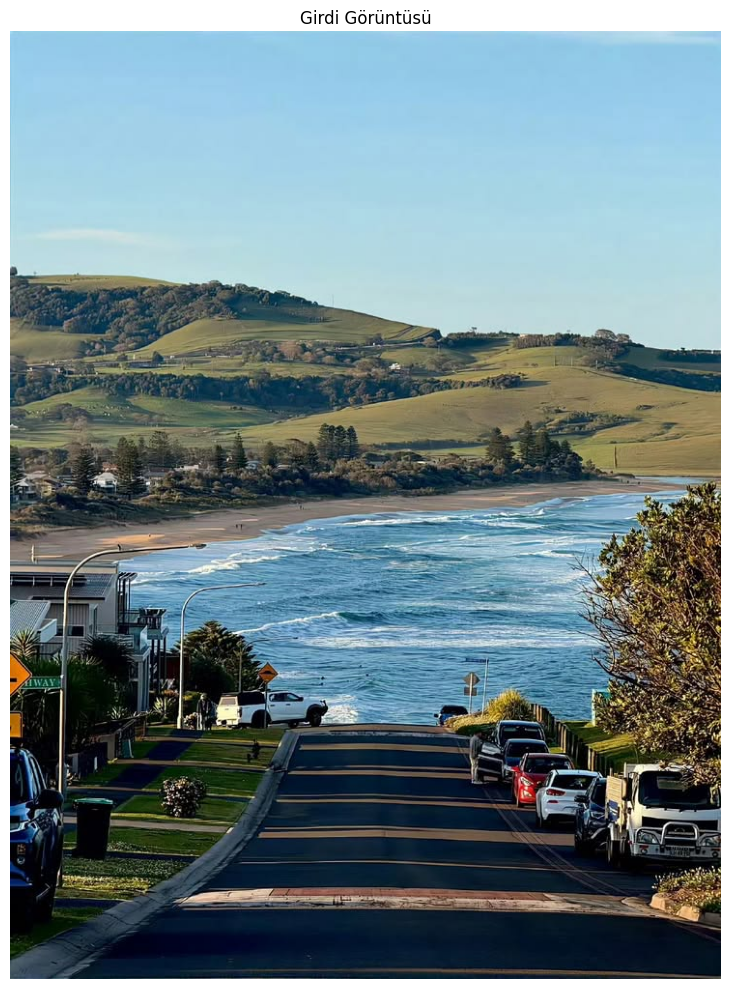

In [9]:
# ── Görüntü oku ───────────────────────────────────────────────────────────────
image_bgr = cv2.imread(IMAGE_PATH)

# Dosya bulunamazsa anlamlı hata ver
if image_bgr is None:
    sys.exit(
        f"HATA: Görüntü okunamadı → '{IMAGE_PATH}'\n"
        f"Colab 'Files' panelinden '{IMAGE_NAME}' dosyasını yükleyin."
    )

# BGR → RGB (SAM ve matplotlib RGB bekler)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

h, w, c = image_rgb.shape
print(f"Görüntü boyutu: {w}x{h} px, {c} kanal")

# Önizleme
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Girdi Görüntüsü")
plt.tight_layout()
plt.show()


## 6 — Otomatik Maske Üretimi
SAM, resmi küçük parçalara (gridlere) böler ve her bir noktada "Burada bir nesne var mı?" diye sorar. Bulduğu her nesne için bir "maske" (nesnenin kapladığı alan) üretir.


`SamAutomaticMaskGenerator` parametrelerini aşağıda açıkladık.
Varsayılan değerler çoğu durumda iyidir; ancak özelleştirebilirsiniz.

| Parametre | Varsayılan | Açıklama |
|---|---|---|
| `points_per_side` | 32 | Izgara yoğunluğu; artırmak daha küçük nesneleri bulur, yavaşlatır |
| `pred_iou_thresh` | 0.88 | Maske kalite eşiği (0–1); düşürünce daha fazla (gürültülü) maske gelir |
| `stability_score_thresh` | 0.95 | Maske kararlılık eşiği |
| `min_mask_region_area` | 100 | Piksel cinsinden minimum nesne alanı; küçük parçaları filtreler |

Sonuçlar `sam_result` listesinde döner. Her eleman bir `dict`'tir:
- `segmentation`: boolean maske (H×W numpy array)
- `area`: piksel sayısı
- `predicted_iou`: model güven skoru (0–1)
- `bbox`: [x, y, w, h]
- `stability_score`: kararlılık skoru


In [10]:
# ── Maske üretici oluştur ─────────────────────────────────────────────────────
mask_generator = SamAutomaticMaskGenerator(
    model                   = sam,
    points_per_side         = 32,       # Artırınca daha ince ayrım, yavaşlar
    pred_iou_thresh         = 0.88,     # Düşür → daha fazla maske
    stability_score_thresh  = 0.95,
    min_mask_region_area    = 100,      # 100 px²'den küçük nesneleri görmezden gel
)

print("Maskeleme başlıyor… (GPU'ya göre 10–60 sn sürebilir)")
sam_result = mask_generator.generate(image_rgb)

# Özet istatistik
areas = [m["area"] for m in sam_result]
ious  = [m["predicted_iou"] for m in sam_result]
print(f"\nBulunan nesne sayısı : {len(sam_result)}")
print(f"Ortalama alan        : {sum(areas)/len(areas):.0f} px²")
print(f"Ortalama güven skoru : {sum(ious)/len(ious):.3f}")


Maskeleme başlıyor… (GPU'ya göre 10–60 sn sürebilir)

Bulunan nesne sayısı : 111
Ortalama alan        : 5880 px²
Ortalama güven skoru : 0.940


## 7 — Maskeleri Görselleştirme ve Kaydetme
Şu an elimizde sadece sayısal veriler var. supervision kütüphanesini kullanarak bu verileri orijinal resmimizin üzerine renkli birer katman olarak dizeceğiz.



Sonuç `.png` olarak kaydedilmektedir. JPEG kayıplı sıkıştırma uyguladığından
piksel sınırları bozulabilir; segmentasyon çıktıları için PNG tercih edilir.


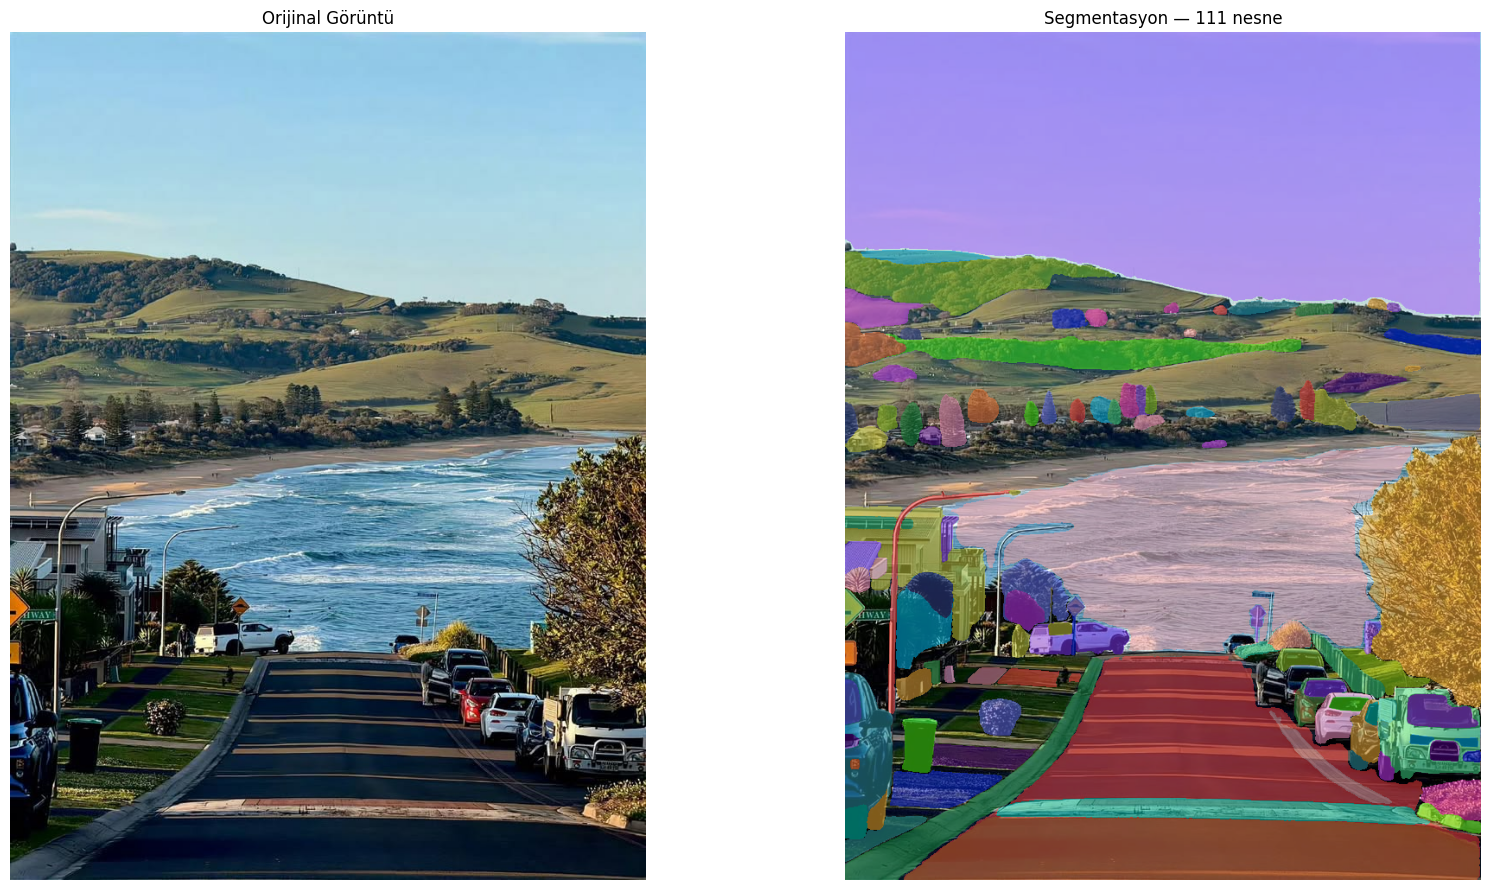

Kaydedildi: /content/segmentasyon_sonucu.png  (904.4 KB)


In [11]:
# ── Detections nesnesine dönüştür ─────────────────────────────────────────────
detections = sv.Detections.from_sam(sam_result=sam_result)

# ── Maskeli görüntü oluştur ───────────────────────────────────────────────────
mask_annotator = sv.MaskAnnotator(
    color_lookup = sv.ColorLookup.INDEX,
    opacity      = 0.5,   # Şeffaflık: 0 (görünmez) – 1 (opak)
)
annotated_image = mask_annotator.annotate(
    scene      = image_bgr.copy(),  # Orijinal resmi bozmamak için .copy()
    detections = detections,
)

# ── Ekranda göster ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(image_rgb)
axes[0].set_title("Orijinal Görüntü")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Segmentasyon — {len(sam_result)} nesne")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ── Kaydet ───────────────────────────────────────────────────────────────────
success = cv2.imwrite(RESULT_PATH, annotated_image)
if success:
    size_kb = os.path.getsize(RESULT_PATH) / 1024
    print(f"Kaydedildi: {RESULT_PATH}  ({size_kb:.1f} KB)")
else:
    print(f"HATA: Dosya kaydedilemedi → {RESULT_PATH}")


## 8 — (Opsiyonel) GPU Belleğini Temizle

Aynı oturumda farklı bir model deneycekseniz bu hücreyi çalıştırın.


In [ ]:
# ── GPU belleğini serbest bırak ───────────────────────────────────────────────
del sam, mask_generator
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Bellek temizlendi.")
